In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df = pd.read_parquet("../data/processed/loans_clean.parquet")
print(f"Loaded {len(df):,} rows")
print(f"Delinquency rate: {df['delq90'].mean():.2%}")

Loaded 2,258,957 rows
Delinquency rate: 11.92%


In [2]:
# Features for the model
features = ["int_rate", "dti", "fico", "loan_amnt", 
            "annual_inc", "revol_util", "delinq_2yrs",
            "open_acc", "pub_rec", "months_obs", "term"]

# Encode grade as numeric (A=1, B=2, ... G=7)
grade_map = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}
df["grade_num"] = df["grade"].map(grade_map)
features.append("grade_num")

# Drop rows missing any feature
model_df = df[features + ["delq90"]].dropna()
print(f"Model dataset: {len(model_df):,} rows")
print(f"Delinquency rate in model set: {model_df['delq90'].mean():.2%}")

X = model_df[features]
y = model_df["delq90"]

# Train/test split — use 2017 and earlier to train, 2018 to test
# (mirrors real-world: train on history, validate on recent)
df_idx = df.loc[model_df.index, "issue_year"]
train_mask = df_idx <= 2017
test_mask  = df_idx == 2018

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"\nTrain: {len(X_train):,} loans ({y_train.mean():.2%} delinquency)")
print(f"Test:  {len(X_test):,} loans  ({y_test.mean():.2%} delinquency)")

Model dataset: 2,257,159 rows
Delinquency rate in model set: 11.92%

Train: 1,763,639 loans (14.76% delinquency)
Test:  493,520 loans  (1.79% delinquency)


In [3]:
# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Fit logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

# Predictions
y_pred_proba = lr.predict_proba(X_test_sc)[:, 1]
y_pred       = lr.predict(X_test_sc)

# AUC on test set
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test AUC: {auc:.4f}")

# Coefficient table
coef_df = pd.DataFrame({
    "feature":     features,
    "coefficient": lr.coef_[0]
}).sort_values("coefficient", ascending=False)

print("\nCoefficients (scaled — larger = stronger predictor):")
print(coef_df.to_string(index=False))

Test AUC: 0.7160

Coefficients (scaled — larger = stronger predictor):
    feature  coefficient
  grade_num     0.686238
       term     0.144241
  loan_amnt     0.087360
   open_acc     0.076986
 revol_util     0.061954
        dti     0.027049
    pub_rec     0.012935
delinq_2yrs     0.004524
       fico    -0.224224
   int_rate    -0.272436
 annual_inc    -0.537155
 months_obs    -0.724301


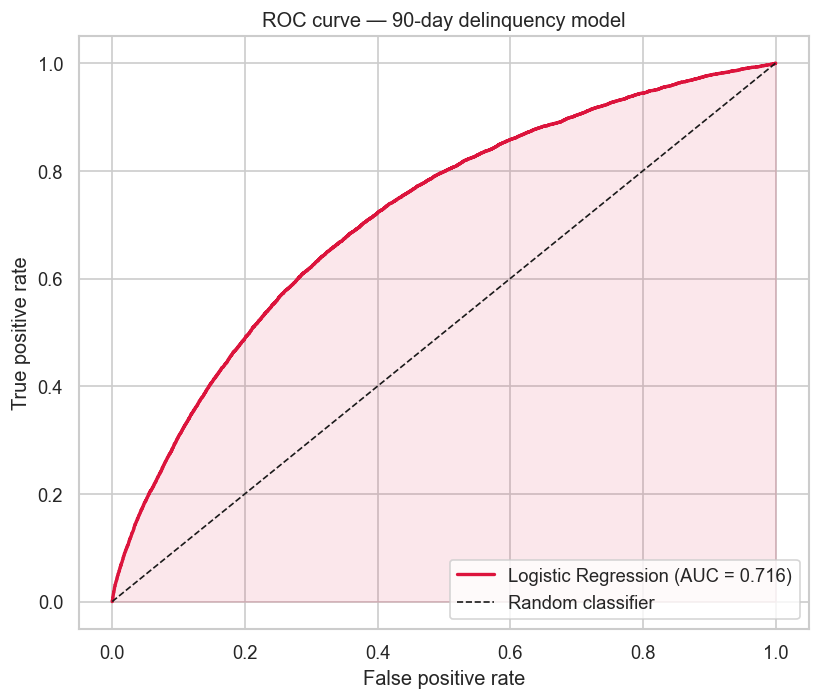

In [4]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="crimson", linewidth=2,
        label=f"Logistic Regression (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")
ax.fill_between(fpr, tpr, alpha=0.1, color="crimson")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — 90-day delinquency model")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("../output/figures/roc_curve.png", dpi=150)
plt.show()

Survival dataset: 100,000 rows


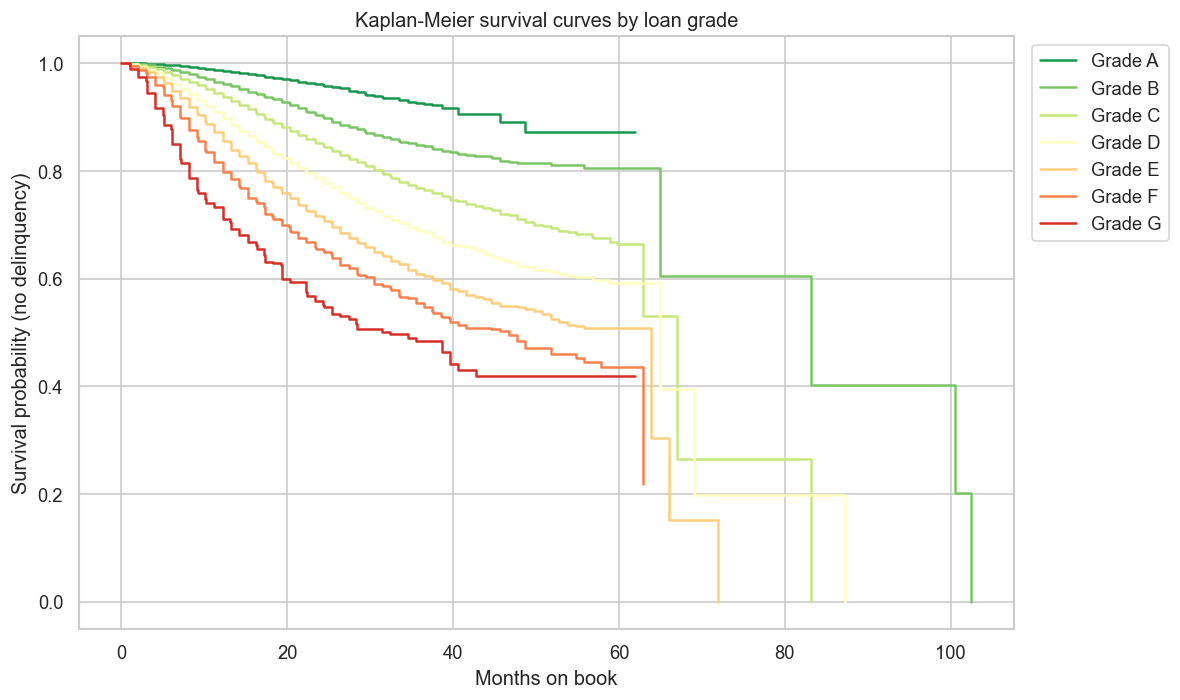

In [5]:
from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter

# Prepare survival dataset
# duration = months_obs, event = delq90
surv_features = ["months_obs", "delq90", "int_rate", 
                 "dti", "fico", "annual_inc", "grade_num", "term"]

surv_df = df[surv_features].dropna()

# Sample for speed (Cox is slow on 2M rows)
surv_sample = surv_df.sample(100_000, random_state=42)
print(f"Survival dataset: {len(surv_sample):,} rows")

# Kaplan-Meier curves by grade
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 7))

for grade_num, grade_letter, color in zip(
        range(1, 8), ["A","B","C","D","E","F","G"], colors):
    mask = surv_sample["grade_num"] == grade_num
    kmf = KaplanMeierFitter()
    kmf.fit(surv_sample.loc[mask, "months_obs"],
            event_observed=surv_sample.loc[mask, "delq90"],
            label=f"Grade {grade_letter}")
    kmf.plot_survival_function(ax=ax, color=color, ci_show=False)

ax.set_xlabel("Months on book")
ax.set_ylabel("Survival probability (no delinquency)")
ax.set_title("Kaplan-Meier survival curves by loan grade")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig("../output/figures/kaplan_meier_by_grade.png",
            dpi=150, bbox_inches="tight")
plt.show()

<lifelines.CoxPHFitter: fitted with 100000 total observations, 87957 right-censored observations>
             duration col = 'months_obs'
                event col = 'delq90'
      baseline estimation = breslow
   number of observations = 100000
number of events observed = 12043
   partial log-likelihood = -128133.071
         time fit was run = 2026-05-29 23:39:39 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
int_rate    5.560   259.800     0.552           4.477           6.643              87.982             767.154
dti         0.001     1.001     0.000           0.000           0.002               1.000               1.002
fico       -0.003     0.997     0.000          -0.004          -0.002               0.996               0.998
annual_inc -0.000     1.000     0.000          -0.000          -0.000               1.000               1.000
grade_num   0.207     1.230     0.021           0.166           0.248               1.180               1.281
term       -0.005     0.995     0.001          -0.007          -0.004               0.993               0.996

            cmp to      z       p  -log2(p)
covariate                                  
int_rate     0.000 10.064 <0.0005    76.734
dti          0.000  2.520   0.012     6.414
fico         0.000 -8.292 <0.0005    52.990
annual_inc   0.000 -5.199 <0.0005    22.255
grade_num    0.000  9.901 <0.0005    74.357
term         0.000 -5.982 <0.0005    28.755
---
Concordance = 0.677
Partial AIC = 256278.142
log-likelihood ratio test = 4039.237 on 6 df
-log2(p) of ll-ratio test = inf

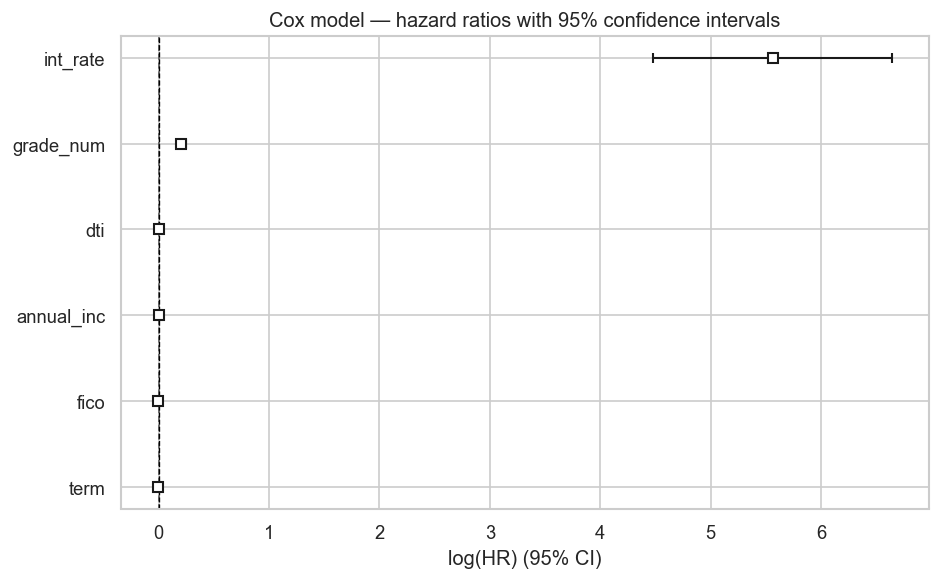

In [6]:
# Cox proportional hazards model
cph = CoxPHFitter()
cph.fit(surv_sample, 
        duration_col="months_obs",
        event_col="delq90")

cph.print_summary(decimals=3)

# Plot hazard ratios
fig, ax = plt.subplots(figsize=(8, 5))
cph.plot(ax=ax)
ax.set_title("Cox model — hazard ratios with 95% confidence intervals")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.savefig("../output/figures/cox_hazard_ratios.png",
            dpi=150, bbox_inches="tight")
plt.show()

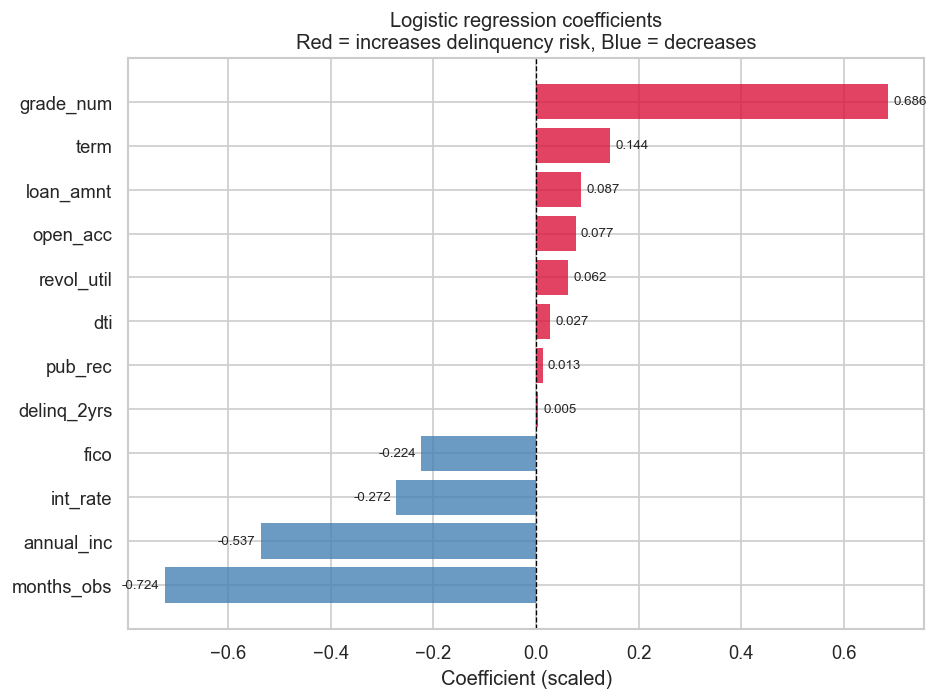

In [7]:
# Coefficient bar chart
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": lr.coef_[0]
}).sort_values("coefficient")

colors = ["crimson" if c > 0 else "steelblue" for c in coef_df["coefficient"]]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(coef_df["feature"], coef_df["coefficient"],
               color=colors, alpha=0.8, edgecolor="none")

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Coefficient (scaled)")
ax.set_title("Logistic regression coefficients\nRed = increases delinquency risk, Blue = decreases")

# Add value labels
for bar, val in zip(bars, coef_df["coefficient"]):
    ax.text(val + (0.01 if val > 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center",
            ha="left" if val > 0 else "right", fontsize=8)

plt.tight_layout()
plt.savefig("../output/figures/logistic_coefficients.png", dpi=150)
plt.show()

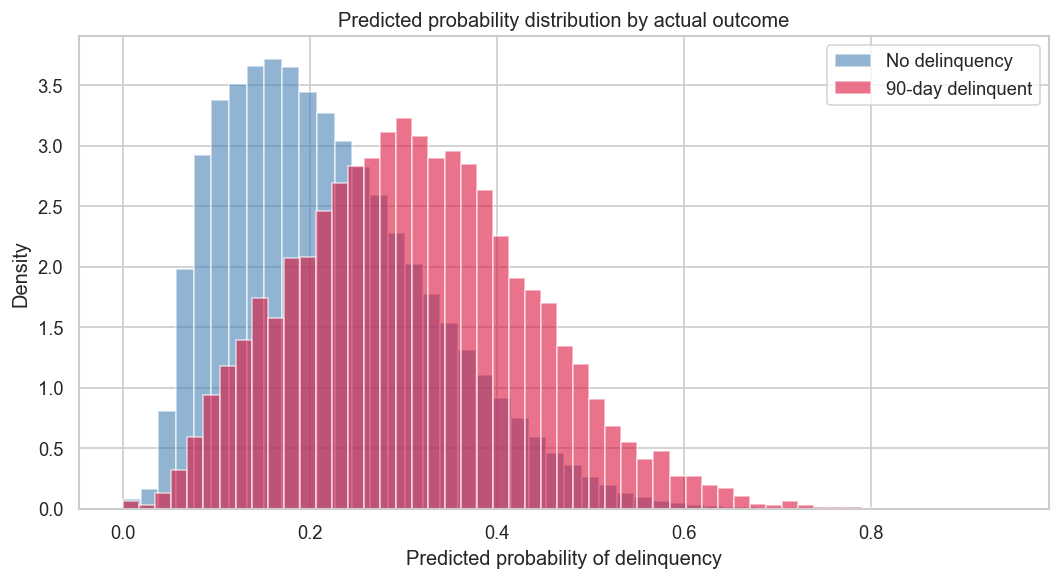

In [8]:
# Predicted probability distribution
y_pred_proba_train = lr.predict_proba(X_train_sc)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.6,
        color="steelblue", label="No delinquency", density=True)
ax.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.6,
        color="crimson", label="90-day delinquent", density=True)

ax.set_xlabel("Predicted probability of delinquency")
ax.set_ylabel("Density")
ax.set_title("Predicted probability distribution by actual outcome")
ax.legend()

plt.tight_layout()
plt.savefig("../output/figures/predicted_probability_dist.png", dpi=150)
plt.show()


In [9]:
# ── Stage 2: Loss Given Default (LGD) ────────────────────────────────────────
# Only look at loans that actually went delinquent
lgd_df = df[df["delq90"] == 1].copy()

# Calculate loss amount and LGD ratio
lgd_df["loss_amt"] = (lgd_df["loan_amnt"] - lgd_df["total_pymnt"]).clip(lower=0)
lgd_df["lgd"] = (lgd_df["loss_amt"] / lgd_df["loan_amnt"]).clip(0, 1)

print(f"Defaulted loans: {len(lgd_df):,}")
print(f"\nLGD summary:")
print(lgd_df["lgd"].describe().round(3))
print(f"\nMean loss per defaulted loan: ${lgd_df['loss_amt'].mean():,.0f}")
print(f"Total loss across portfolio:  ${lgd_df['loss_amt'].sum():,.0f}")

Defaulted loans: 269,289

LGD summary:
count    269289.000
mean          0.467
std           0.263
min           0.000
25%           0.265
50%           0.495
75%           0.677
max           1.000
Name: lgd, dtype: float64

Mean loss per defaulted loan: $7,402
Total loss across portfolio:  $1,993,221,626


In [10]:
import statsmodels.api as sm

# Features for LGD model
lgd_features = ["int_rate", "dti", "fico", "loan_amnt",
                "annual_inc", "revol_util", "grade_num", "term", "months_obs"]

lgd_clean = lgd_df[lgd_features + ["lgd"]].dropna()

X_lgd = lgd_clean[lgd_features]
y_lgd = lgd_clean["lgd"]

# Add constant for intercept
X_lgd_sm = sm.add_constant(X_lgd)

# Fit OLS
ols_model = sm.OLS(y_lgd, X_lgd_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    lgd   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                 7.846e+04
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        21:50:20   Log-Likelihood:             1.5055e+05
No. Observations:              269103   AIC:                        -3.011e+05
Df Residuals:                  269093   BIC:                        -3.010e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4408      0.009     51.198      0.0

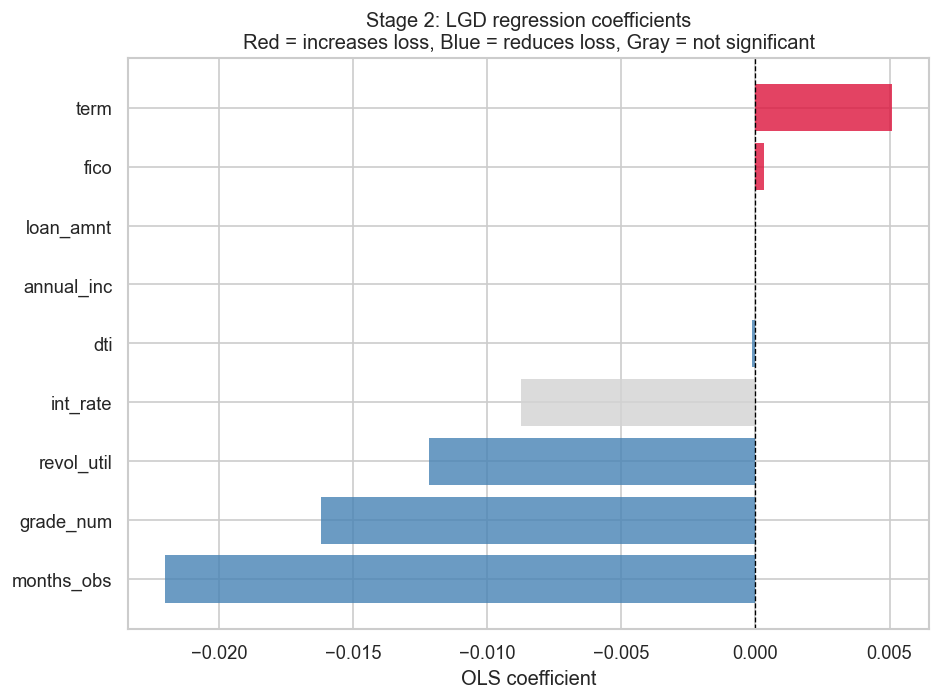


EXPECTED LOSS BY GRADE (PD × LGD × Exposure)
Grade A:  PD=3.28%  LGD=45.14%  EL=$93.7M
Grade B:  PD=7.94%  LGD=45.13%  EL=$336.8M
Grade C:  PD=13.21%  LGD=46.93%  EL=$605.2M
Grade D:  PD=18.90%  LGD=47.29%  EL=$455.0M
Grade E:  PD=26.70%  LGD=47.13%  EL=$297.7M
Grade F:  PD=34.91%  LGD=47.92%  EL=$133.6M
Grade G:  PD=38.09%  LGD=51.31%  EL=$48.4M

Total Expected Loss: $1970.3M


In [11]:
# Plot OLS coefficients
coef_table = pd.DataFrame({
    "feature":     lgd_features,
    "coef":        ols_model.params[1:].values,
    "pvalue":      ols_model.pvalues[1:].values,
})
coef_table["significant"] = coef_table["pvalue"] < 0.05
coef_table = coef_table.sort_values("coef")

colors = ["crimson" if (s and c > 0) else
          "steelblue" if (s and c < 0) else
          "lightgray"
          for s, c in zip(coef_table["significant"], coef_table["coef"])]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(coef_table["feature"], coef_table["coef"],
        color=colors, alpha=0.8, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("OLS coefficient")
ax.set_title("Stage 2: LGD regression coefficients\n"
             "Red = increases loss, Blue = reduces loss, Gray = not significant")
plt.tight_layout()
plt.savefig("../output/figures/lgd_coefficients.png", dpi=150)
plt.show()

# ── Expected Loss = PD × LGD × Exposure ─────────────────────────────────────
print("\n" + "="*55)
print("EXPECTED LOSS BY GRADE (PD × LGD × Exposure)")
print("="*55)

grade_pd  = df.groupby("grade")["delq90"].mean()
grade_lgd = lgd_df.groupby("grade")["lgd"].mean()
grade_exp = df.groupby("grade")["loan_amnt"].sum()

el = pd.DataFrame({
    "PD":       grade_pd,
    "LGD":      grade_lgd,
    "Exposure": grade_exp,
}).assign(EL=lambda x: x["PD"] * x["LGD"] * x["Exposure"])

for grade, row in el.iterrows():
    print(f"Grade {grade}:  PD={row['PD']:.2%}  "
          f"LGD={row['LGD']:.2%}  "
          f"EL=${row['EL']/1e6:.1f}M")

print(f"\nTotal Expected Loss: ${el['EL'].sum()/1e6:.1f}M")

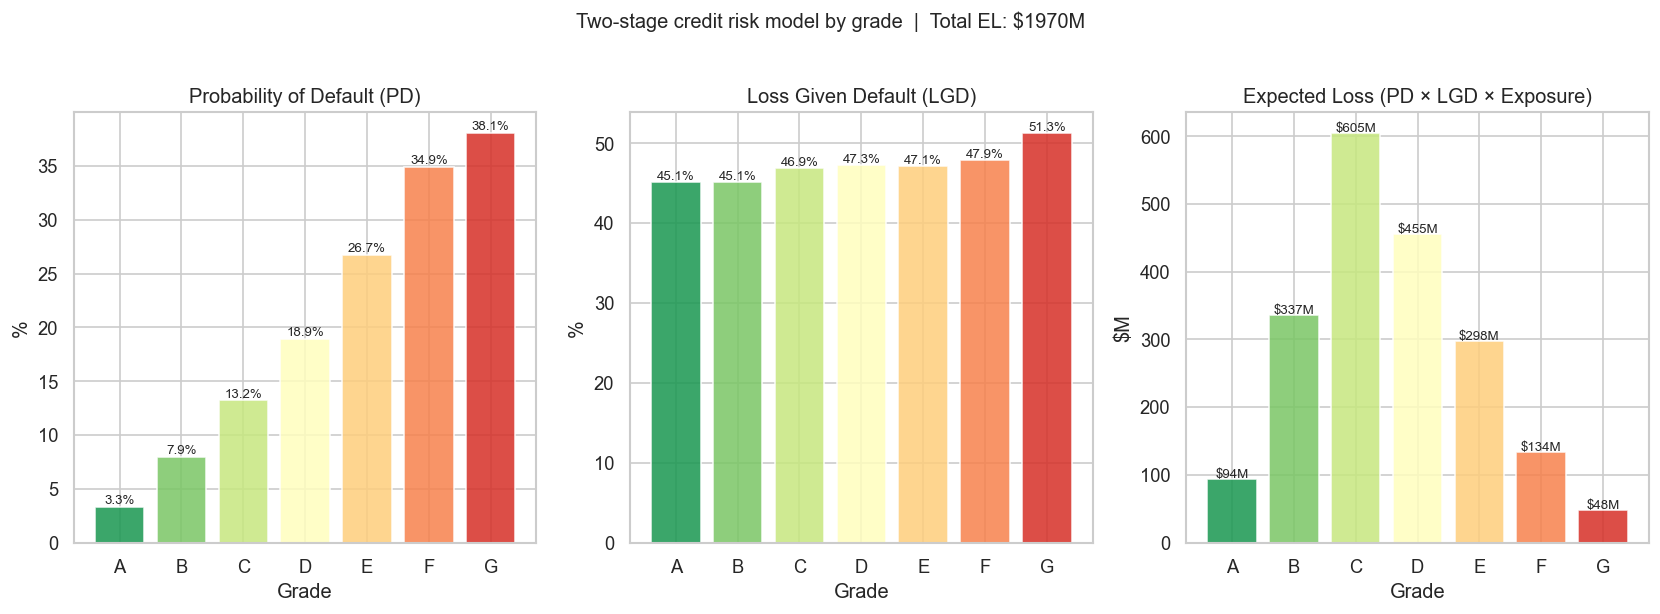

In [12]:
# Expected Loss bar chart by grade
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

grades = el.index.tolist()
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(grades)))

# PD by grade
axes[0].bar(grades, el["PD"] * 100, color=colors, alpha=0.85)
axes[0].set_title("Probability of Default (PD)")
axes[0].set_ylabel("%")
for i, v in enumerate(el["PD"] * 100):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=8)

# LGD by grade
axes[1].bar(grades, el["LGD"] * 100, color=colors, alpha=0.85)
axes[1].set_title("Loss Given Default (LGD)")
axes[1].set_ylabel("%")
for i, v in enumerate(el["LGD"] * 100):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=8)

# Expected Loss by grade
axes[2].bar(grades, el["EL"] / 1e6, color=colors, alpha=0.85)
axes[2].set_title("Expected Loss (PD × LGD × Exposure)")
axes[2].set_ylabel("$M")
for i, v in enumerate(el["EL"] / 1e6):
    axes[2].text(i, v + 2, f"${v:.0f}M", ha="center", fontsize=8)

for ax in axes:
    ax.set_xlabel("Grade")

plt.suptitle(f"Two-stage credit risk model by grade  |  "
             f"Total EL: ${el['EL'].sum()/1e6:.0f}M",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../output/figures/expected_loss_by_grade.png",
            dpi=150, bbox_inches="tight")
plt.show()